UCI Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0      148             72             35        0  33.6   
1       85             66             29        0  26.6   
2      183             64              0        0  23.3   
3       89             66             23       94  28.1   
4      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Pima Indians Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0      120             70             30        0  35.0   
1      150             80             32      150  34.5   
2      100             60             20       85  28.0   
3      130             78             28      120  32.4   
4      140        

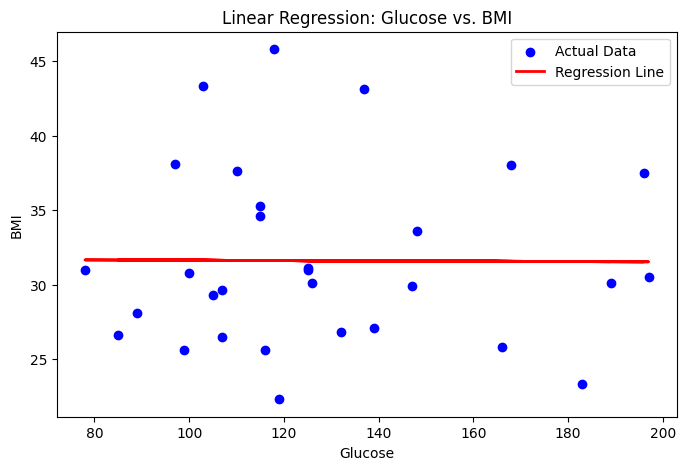


Linear Regression (Predicting BMI using Glucose):
R2 Score: 0.8577


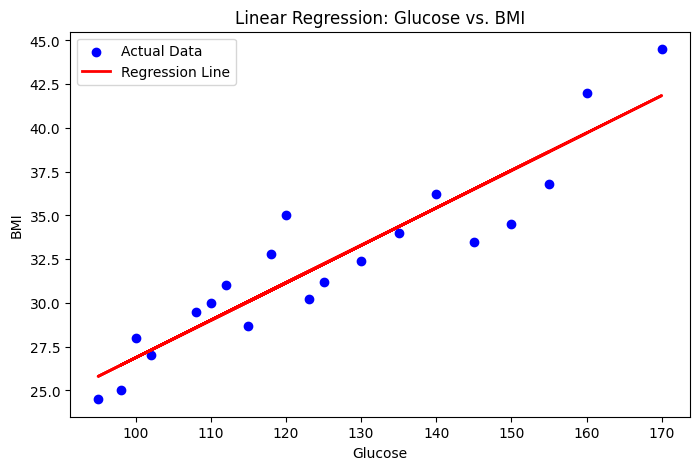


Logistic Regression (Predicting Outcome using ['Glucose', 'BloodPressure', 'BMI', 'Age']):
Accuracy Score: 0.8333

Logistic Regression (Predicting Outcome using ['Glucose', 'BloodPressure', 'BMI', 'Age']):
Accuracy Score: 0.7500


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

# Load the Datasets

uci_diabetes = pd.read_csv("uci_diabetes.csv")
pima_diabetes = pd.read_csv("pima_diabetes.csv")

# Display First Few Rows

print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())

# Linear Regression: Glucose vs BMI

def linear_regression_analysis(df, x_column, y_column):

    X = df[[x_column]]       # Independent variable
    Y = df[y_column]         # Dependent variable

    # Create and train model
    model = LinearRegression()
    model.fit(X, Y)

    # Make predictions
    Y_pred = model.predict(X)

    # Calculate R2 score
    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression (Predicting {y_column} using {x_column}):")
    print(f"R2 Score: {r2:.4f}")

    # Plot actual data
    plt.figure(figsize=(8, 5))
    plt.scatter(X, Y, color="blue", label="Actual Data")

    # Plot regression line
    plt.plot(
        X,
        Y_pred,
        color="red",
        linewidth=2,
        label="Regression Line"
    )

    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"Linear Regression: {x_column} vs. {y_column}")
    plt.legend()
    plt.show()


# Apply Linear Regression on both datasets
linear_regression_analysis(
    uci_diabetes,
    "Glucose",
    "BMI"
)

linear_regression_analysis(
    pima_diabetes,
    "Glucose",
    "BMI"
)

# Logistic Regression: Predicting Diabetes

def logistic_regression_analysis(df, features, target):

    X = df[features]
    Y = df[target]

    # Split dataset into training and testing sets
    X_train, X_test, Y_train, Y_test = train_test_split(
        X,
        Y,
        test_size=0.2,
        random_state=42
    )

    # Create and train Logistic Regression model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, Y_train)

    # Make predictions
    Y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(Y_test, Y_pred)

    print(f"\nLogistic Regression (Predicting {target} using {features}):")
    print(f"Accuracy Score: {accuracy:.4f}")

# Select Features and Target
features = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age"
]

target = "Outcome"

# Apply Logistic Regression on Both Datasets
logistic_regression_analysis(
    uci_diabetes,
    features,
    target
)

logistic_regression_analysis(
    pima_diabetes,
    features,
    target
)
